# Generate some data using a linear superposition of several timeseries

In [61]:
import numpy as np
import matplotlib.pyplot as plt

n = 360
t = np.arange(1, n+1)
trend = 2 + 0.01 * t
seasonal = np.sin(2 * np.pi * t / 12)
cyclical = np.sin(2 * np.pi * t / 60)
irregular = np.random.randn(n)
ystationary = seasonal + cyclical #+ irregular
ynonstationary=trend+seasonal + cyclical + irregular
print("Frequencies present are",1 / 12,1 / 60)

Frequencies present are 0.08333333333333333 0.016666666666666666


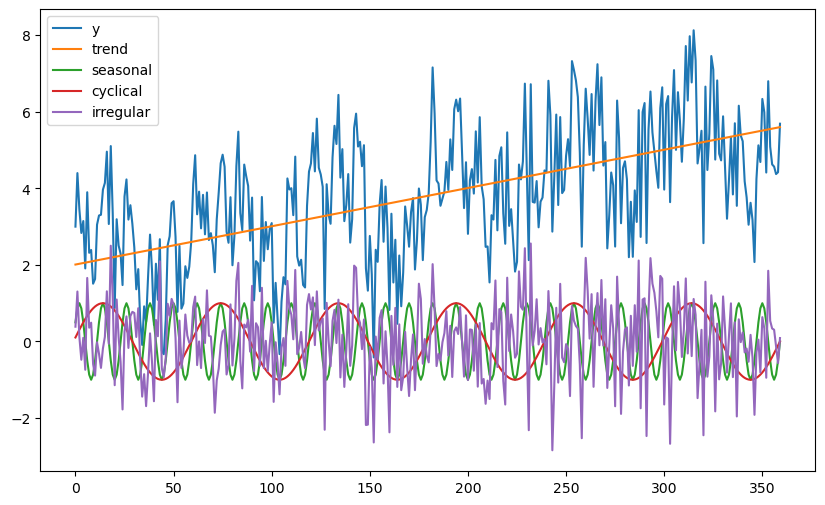

In [62]:
plt.subplots(figsize=(10, 6))
plt.plot(ynonstationary, label="y")
plt.plot(trend, label="trend")
plt.plot(seasonal, label="seasonal")
plt.plot(cyclical, label="cyclical")
plt.plot(irregular, label="irregular")
plt.legend()

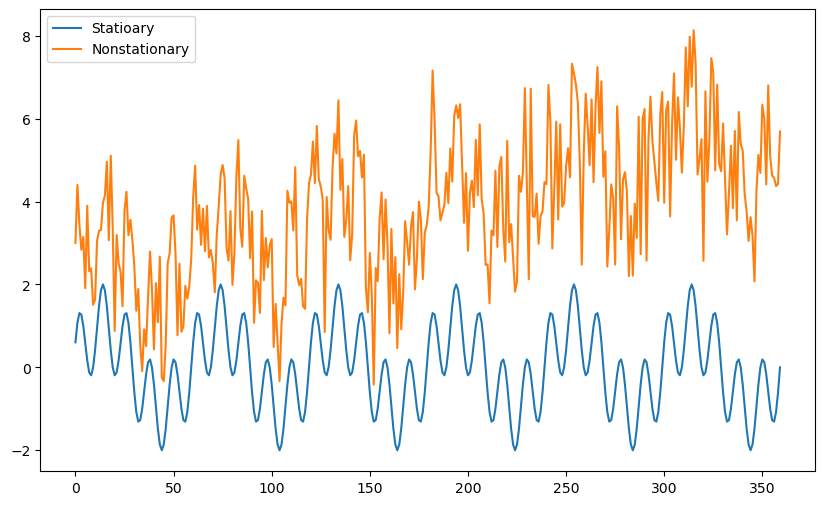

In [63]:
plt.subplots(figsize=(10, 6))
plt.plot(ystationary,label="Statioary")
plt.plot(ynonstationary, label="Nonstationary")
plt.legend()

# FFT

* Requires data to be stationary 

* Requirs that 

* All the modes are orthogonal

*

In [64]:
from scipy.fft import fft, fftfreq, fftshift

# Calculate values of x after fft
x_fft = fftfreq(n, 1)
x_fft = fftshift(x_fft)

## FFT on stationary data

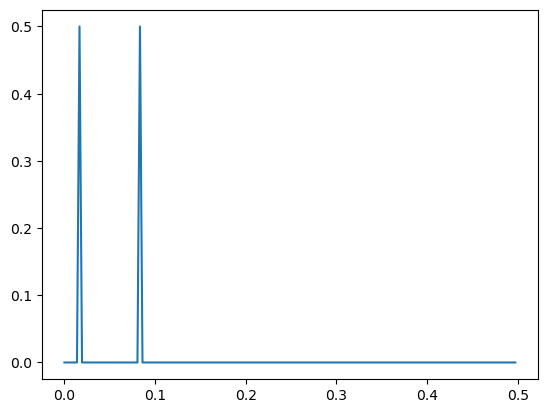

In [65]:
fftYstationary = fftshift(fft(ystationary))
plt.plot(x_fft[n//2:], 1/n * abs(fftYstationary[n//2:]), label=f"FFT of stationary data")

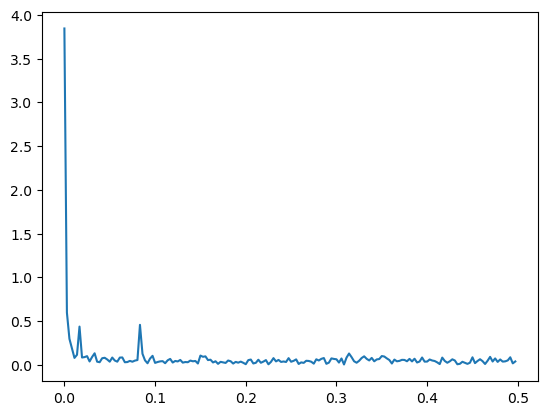

In [66]:
fftYnonstationary = fftshift(fft(ynonstationary))
plt.plot(x_fft[n//2:], 1/n * abs(fftYnonstationary[n//2:]), label=f"FFT of non stationary data")

# Empirical mode decomposition

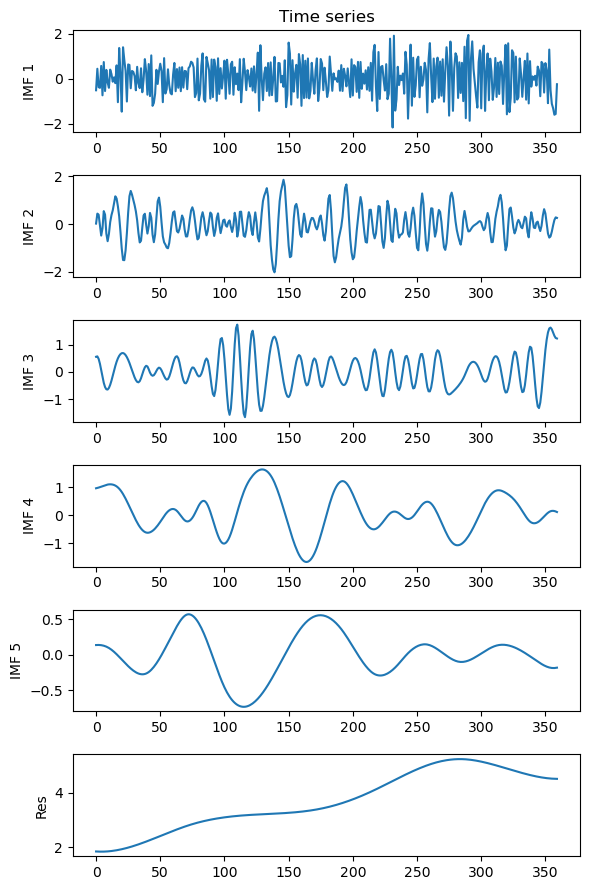

In [71]:
from PyEMD import EMD, Visualisation

# Calculate IMFs of y
emd = EMD()
StationaryIMFs = emd(ystationary,max_imf=5)
# Plot IMFs using built in visualization functionality
Visualisation(emd).plot_imfs()

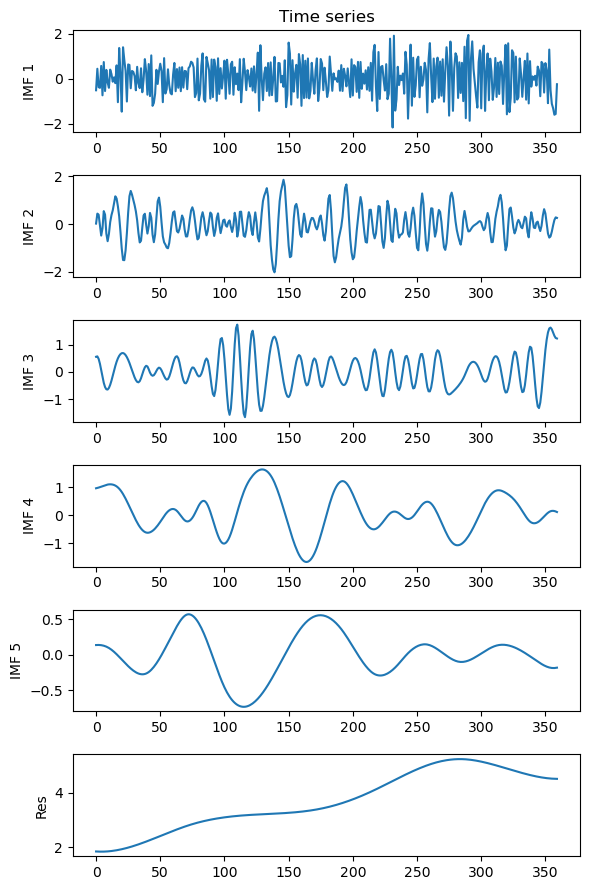

In [75]:
from PyEMD import EMD, Visualisation

# Calculate IMFs of y
emd = EMD()
NonStationaryIMFs = emd(ynonstationary,max_imf=5)
# Plot IMFs using built in visualization functionality
Visualisation(emd).plot_imfs()

In [77]:
# Take the FFT of all IMFs
ystationary_fft = []
ynonstationary_fft = []
for imf in StationaryIMFs:
    ystationary_fft.append(fftshift(fft(imf)))

for imf in NonStationaryIMFs:
    ynonstationary_fft.append(fftshift(fft(imf)))
# Calculate fft of the seasonal and cyclical trend for visualization
seasonal_fft = fft(seasonal)
seasonal_fft = fftshift(seasonal_fft)

cyclical_fft = fft(cyclical)
cyclical_fft = fftshift(cyclical_fft)

irregular_fft = fft(irregular)
irregular_fft = fftshift(irregular_fft)

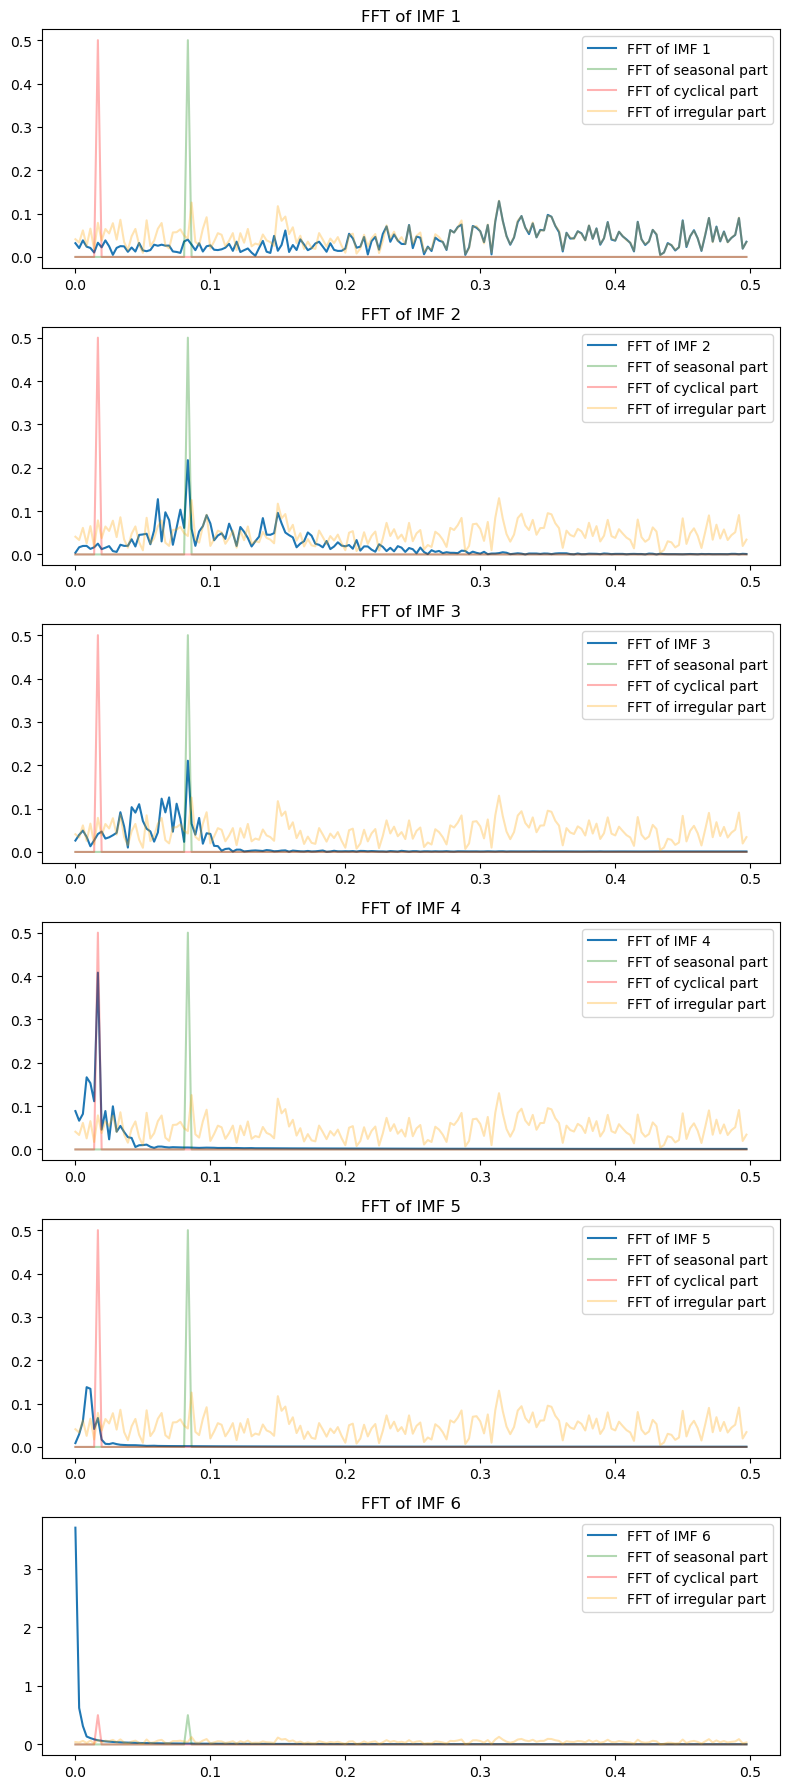

In [78]:
plt.subplots(len(ynonstationary_fft), 1, figsize=(8, 3 * len(ynonstationary_fft)))
for i, y in enumerate(ynonstationary_fft):
    plt.subplot(len(ynonstationary_fft), 1, i+1)
    plt.plot(x_fft[n//2:], 1/n * abs(y[n//2:]), label=f"FFT of IMF {i+1}")
    plt.plot(x_fft[n//2:], 1/n * abs(seasonal_fft[n//2:]), label="FFT of seasonal part", color="green", alpha=0.3)
    plt.plot(x_fft[n//2:], 1/n * abs(cyclical_fft[n//2:]), label="FFT of cyclical part", color="red", alpha=0.3)  
    plt.plot(x_fft[n//2:], 1/n * abs(irregular_fft[n//2:]), label="FFT of irregular part", color="orange", alpha=0.3) 
    plt.title(f"FFT of IMF {i+1}")
    plt.legend()
plt.tight_layout()